# Hospital Patient Satisfaction Analytics & Prediction

## 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the
distribution, patterns, relationships, and unusual observations
present in the patient-flow and patient-satisfaction data.

### Objectives

- Understand the distribution of patient satisfaction scores
- Analyze patient demographics
- Analyze patient waiting time
- Compare satisfaction across different patient groups
- Identify relationships between variables
- Detect unusual patterns and potential outliers
- Generate meaningful business insights

In [1]:
import pandas as pd
file_path="/content/drive/MyDrive/datasets2026/healthcare_analytics_patient_flow_data.csv"
df=pd.read_csv(file_path)
df.shape
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [2]:
# Correct inconsistent gender category
df["Patient Gender"] = df["Patient Gender"].replace(
    "Femaleemale",
    "Female"
)

# Convert admission date
df["Patient Admission Date"] = pd.to_datetime(
    df["Patient Admission Date"],
    errors="coerce"
)

# Convert admission time
df["Patient Admission Time"] = pd.to_datetime(
    df["Patient Admission Time"],
    format="%I:%M:%S %p",
    errors="coerce"
)

# Create missing-satisfaction indicator
df["Satisfaction_Missing"] = df["Patient Satisfaction Score"].isnull()

print("Cleaning steps applied successfully.")
print("Shape:", df.shape)

Cleaning steps applied successfully.
Shape: (9216, 12)


In [3]:
satisfaction_counts=df["Patient Satisfaction Score"].value_counts(
    dropna=False
).sort_index()
print(satisfaction_counts)

Patient Satisfaction Score
0.0      222
1.0      246
2.0      204
3.0      228
4.0      248
5.0      221
6.0      231
7.0      256
8.0      218
9.0      222
10.0     221
NaN     6699
Name: count, dtype: int64


In [4]:
#ok now we want to find the satisfaction percentage
satisfaction_percentage=(df["Patient Satisfaction Score"].
value_counts(normalize=True).sort_index()*100)
print(satisfaction_percentage.round(3))

Patient Satisfaction Score
0.0      8.820
1.0      9.774
2.0      8.105
3.0      9.058
4.0      9.853
5.0      8.780
6.0      9.178
7.0     10.171
8.0      8.661
9.0      8.820
10.0     8.780
Name: proportion, dtype: float64


From this we got the patients that give 7 score is about the 10.17% of the  2517 records

In [5]:
#Next we want to find the mean median mode of the satisfaction score
mean_satisfaction=df["Patient Satisfaction Score"].mean().round(3)
median_satisfaction=df["Patient Satisfaction Score"].median()
mode_satisfaction=df["Patient Satisfaction Score"].mode()
print(mean_satisfaction)
print(median_satisfaction)
print(mode_satisfaction)

4.992
5.0
0    7.0
Name: Patient Satisfaction Score, dtype: float64


Text(0, 0.5, 'Number of patients')

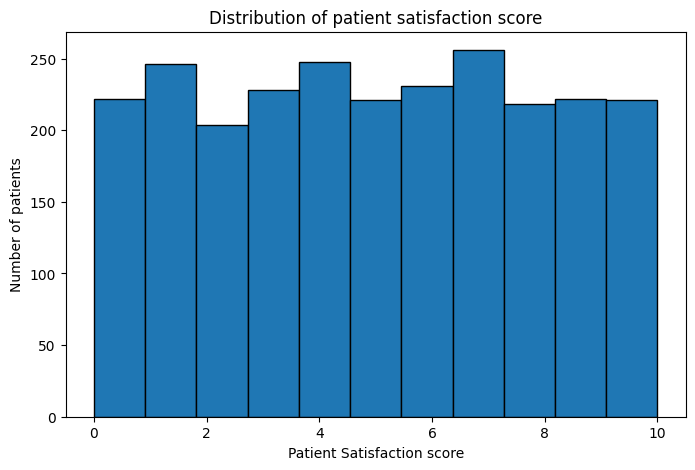

In [6]:
#next we have to plot the satisfaction score
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df["Patient Satisfaction Score"].dropna().plot(
    kind="hist",
    bins=11,
    edgecolor="black"
)
plt.title("Distribution of patient satisfaction score")
plt.xlabel("Patient Satisfaction score")
plt.ylabel("Number of patients")

Text(0, 0.5, 'NUmber of patiensts')

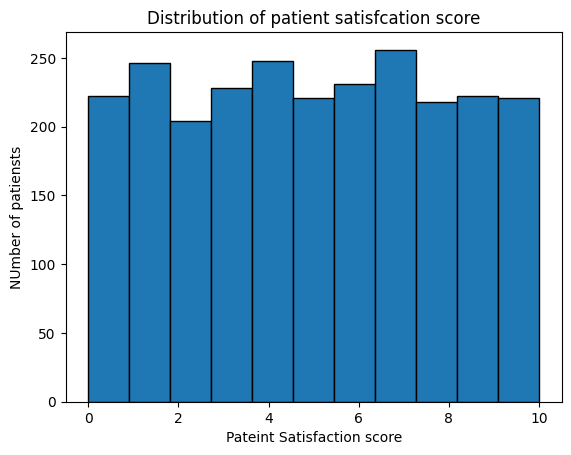

In [7]:
df["Patient Satisfaction Score"].dropna().plot(
    kind="hist",
    bins=11,
    edgecolor="black"
)
plt.title("Distribution of patient satisfcation score")
plt.xlabel("Pateint Satisfaction score")
plt.ylabel("NUmber of patiensts")

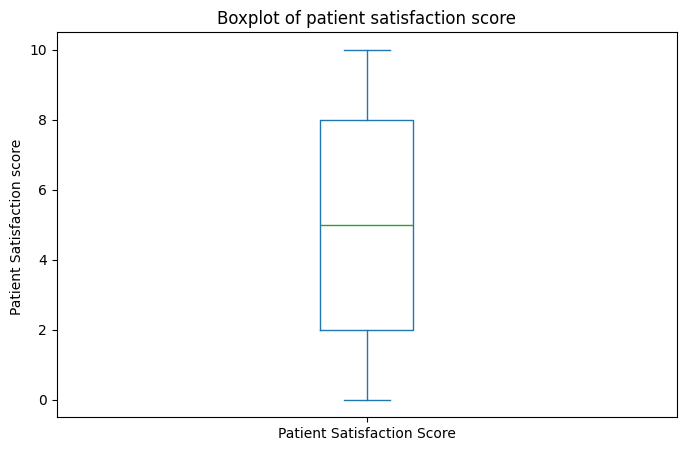

In [8]:
plt.figure(figsize=(8,5))
df["Patient Satisfaction Score"].dropna().plot(
    kind="box"
)
plt.title("Boxplot of patient satisfaction score")
plt.ylabel("Patient Satisfaction score ")
plt.show()

In [9]:
satisfaction=df["Patient Satisfaction Score"].dropna()
Q1=satisfaction.quantile(0.25)
Q3=satisfaction.quantile(0.75)
IQR=Q3-Q1
print(Q1)
print(Q3)
print(IQR)

2.0
8.0
6.0


In [10]:
lower_bound=Q1-1.5 *IQR
upper_bound=Q3+1.5*IQR

In [11]:
outliers=df[(df["Patient Satisfaction Score"] <lower_bound)|
 (df["Patient Satisfaction Score"]>upper_bound)]

print("the number of the outliers",len(outliers))

the number of the outliers 0


In [12]:
age=df["Patient Age"]
print(age.max())
print(age.min())
print(age.mean().round(2))
print(age.median())


79
1
39.86
39.0


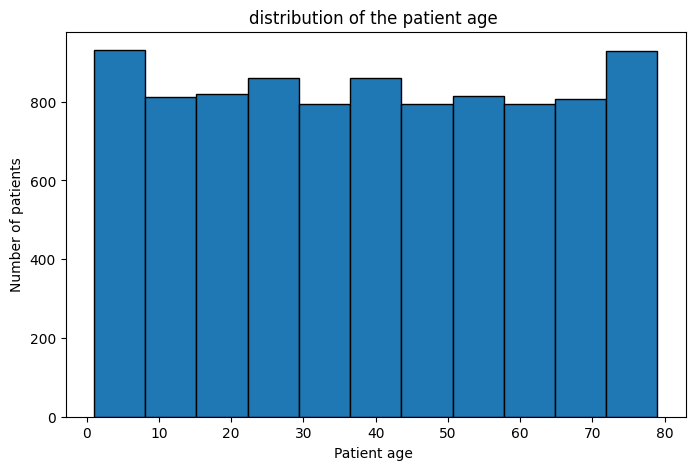

In [13]:
#now we can plot the age histograam graph
plt.figure(figsize=(8,5))
df["Patient Age"].plot(
    kind="hist",
    bins=11,
    edgecolor="black"
)
plt.title("distribution of the patient age ")
plt.xlabel("Patient age ")
plt.ylabel("Number of patients")
plt.show()

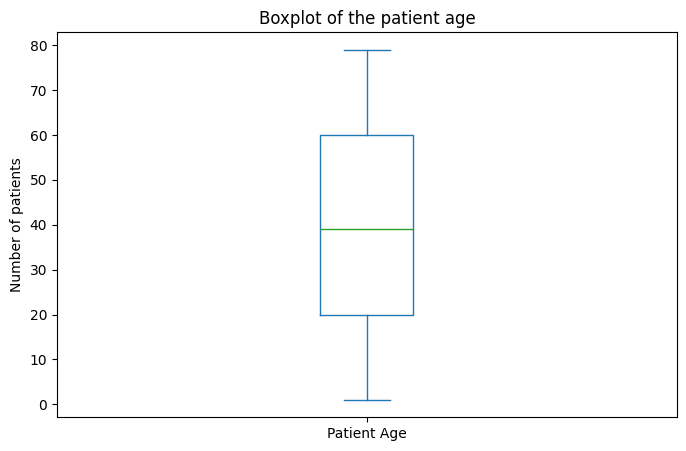

In [14]:
#ok now we have to create the age box plot
plt.figure(figsize=(8,5))
df["Patient Age"].plot(kind="box")
plt.title("Boxplot of the patient age")

plt.ylabel("Number of patients")
plt.show()

In [15]:
#ok next we want to do the quartiles and the iqr of the patient age
age=df["Patient Age"]
Q1=age.quantile(0.25)
Q3=age.quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound,upper_bound)

age_outliers=df[
    (df["Patient Age"] <lower_bound) |
    (df["Patient Age"]> upper_bound)
]
print(len(age_outliers))

20.0 60.0 40.0
-40.0 120.0
0


10
60
35.26
35.0


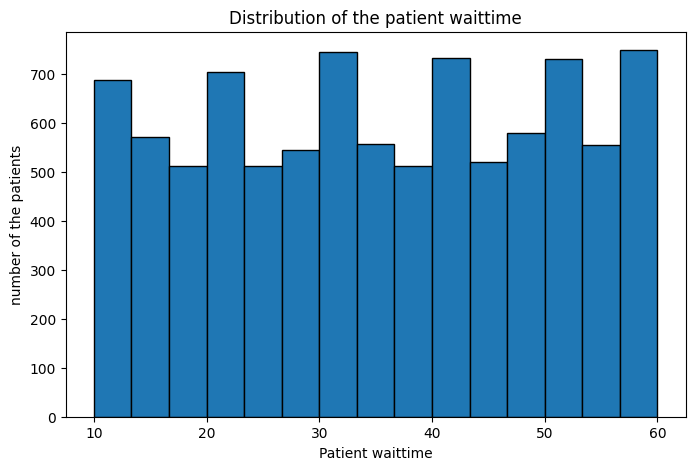

23.0 48.0 25.0
-14.5 85.5
0


In [16]:
# ok now we going to the patient waittime
waittime=df["Patient Waittime"]
print(df["Patient Waittime"].min())
print(df["Patient Waittime"].max())
print(df["Patient Waittime"].mean().round(2))
print(df["Patient Waittime"].median())

plt.figure(figsize=(8,5))
df["Patient Waittime"].plot(
    kind="hist",
    bins=15,
    edgecolor="black"
)
plt.title("Distribution of the patient waittime")
plt.xlabel("Patient waittime")
plt.ylabel("number of the patients")
plt.show()



#ok now we will calculate the Q1,Q3,IQR of the patient waittime
waittime=df["Patient Waittime"]
Q1=waittime.quantile(0.25)
Q3=waittime.quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,IQR)
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR
print(Lower_bound,Upper_bound)

waittime_outliers=df[
    (df["Patient Waittime"]<lower_bound) |
    (df["Patient Waittime"]>upper_bound)
]
print(len(waittime_outliers))

Patient Gender
Male      4729
Female    4487
Name: count, dtype: int64
Patient Gender
Male      51.31
Female    48.69
Name: proportion, dtype: float64


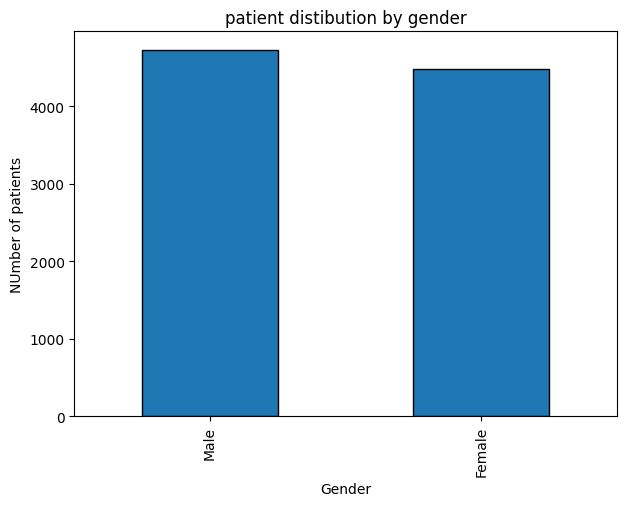

In [17]:
#ok now we go to the gender count
gender_counts=df["Patient Gender"].value_counts()
print(gender_counts)
gender_percentage=(
    df["Patient Gender"].value_counts(normalize=True)*100
)
print(gender_percentage.round(2))
import matplotlib.pyplot as plt
gender_counts.plot(
    kind="bar",
    figsize=(7,5),
    edgecolor="black"
)
plt.title("patient distibution by gender")
plt.xlabel("Gender")
plt.ylabel("NUmber of patients")
plt.show()

                Count      Mean  Median
Patient Gender                         
Female           1206  4.955224     5.0
Male             1311  5.025934     5.0


<Figure size 800x500 with 0 Axes>

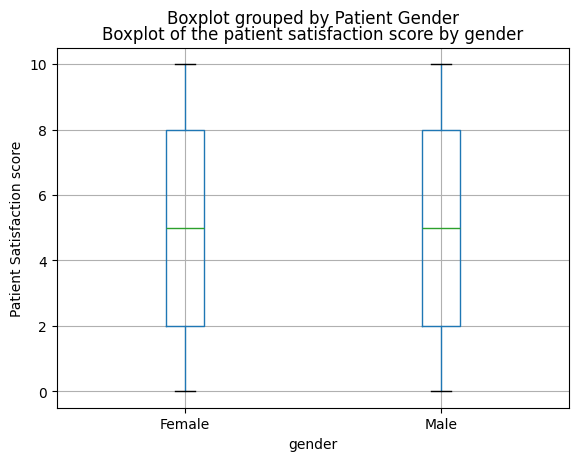

In [18]:
# next we want to find the satisfaction score cout,mean,median of each gender
gender_satisfaction=df.groupby("Patient Gender")["Patient Satisfaction Score"].agg(
    Count="count",
    Mean="mean",
    Median="median"
)
print(gender_satisfaction)


#we have to visualize it
plt.figure(figsize=(8,5))
df.boxplot(
    column="Patient Satisfaction Score",
    by="Patient Gender"
)
plt.title("Boxplot of the patient satisfaction score by gender")
plt.xlabel("gender")
plt.ylabel("Patient Satisfaction score")
plt.show()

In [19]:
#statistical test
#first divided into two groups
#male satisfaction score
male_satisfaction=df.loc[
    df["Patient Gender"] == "Male",
    "Patient Satisfaction Score"
].dropna()
#female satisfaction score
female_satisfaction=df.loc[
    df["Patient Gender"] == "Female",
    "Patient Satisfaction Score"
].dropna()

#then find the length of the female and male satisfaction
print("Female",len(female_satisfaction))
print("male",len(male_satisfaction))

Female 1206
male 1311


In [20]:
#T-Test-it is a test used to find the statistical significant difference of two means group
# it is a type oof hypothesis test
from scipy.stats import ttest_ind
t_stat,p_value=ttest_ind(
    female_satisfaction,
    male_satisfaction,
    equal_var=False
)
print(t_stat)
print(p_value)


-0.5650459650065752
0.5720931292698037


In [21]:
#ok now we are going to the patient race analysis
race_counts=df["Patient Race"].value_counts(dropna=False)
print(race_counts)


Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64


In [22]:
race_percentage=(
    df["Patient Race"].value_counts(normalize=True,dropna=False)*100
)
print(race_percentage.round(2))

Patient Race
White                            27.90
African American                 21.17
Two or More Races                16.89
Asian                            11.50
Declined to Identify             11.18
Pacific Islander                  5.96
Native American/Alaska Native     5.40
Name: proportion, dtype: float64


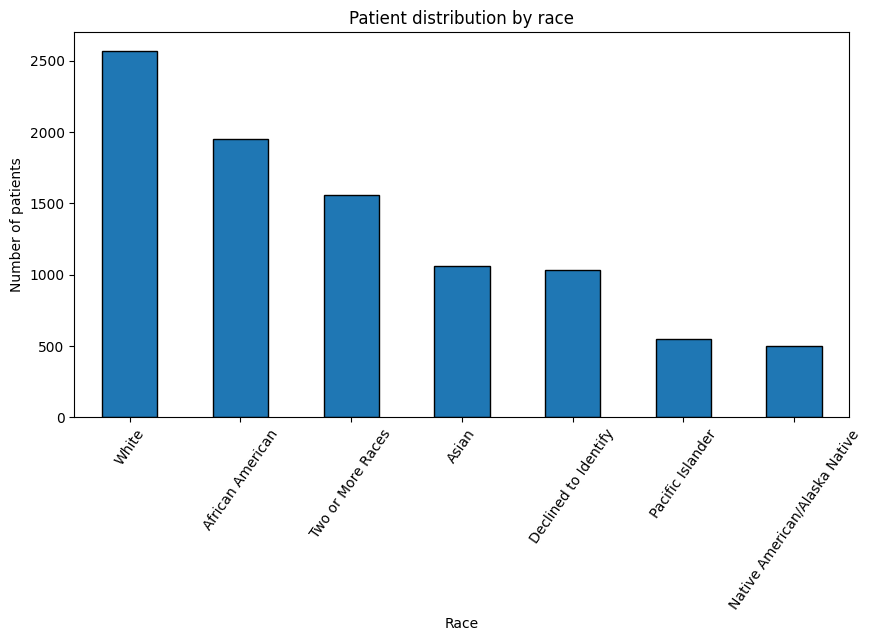

In [23]:
#race distribution visualization
import matplotlib.pyplot as plt
race_counts =df["Patient Race"].value_counts()
plt.figure(figsize=(10,5))
race_counts.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Patient distribution by race")
plt.xlabel("Race")
plt.ylabel("Number of patients")
plt.xticks(rotation=55)
plt.show()


                               Count  Mean  Median
Patient Race                                      
African American                 514  5.07     5.0
Asian                            293  5.01     5.0
Declined to Identify             275  4.97     5.0
Native American/Alaska Native    138  5.12     5.0
Pacific Islander                 147  5.33     6.0
Two or More Races                416  4.83     5.0
White                            734  4.94     5.0


<Figure size 800x500 with 0 Axes>

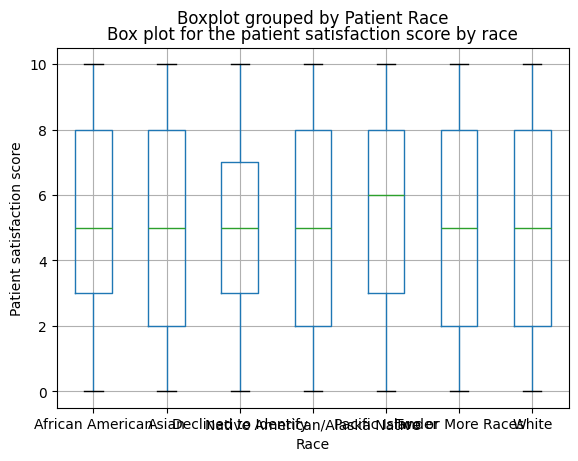

In [24]:
#Race wise satisfaction
race_satisfaction=df.groupby("Patient Race")["Patient Satisfaction Score"].agg(
    Count="count",
    Mean="mean",
    Median="median"
)
print(race_satisfaction.round(2))


#box plot of rrace wise satisfaction
plt.figure(figsize=(8,5))
df.boxplot(
    column="Patient Satisfaction Score",
    by="Patient Race"
)
plt.title('Box plot for the patient satisfaction score by race')
plt.xlabel("Race")
plt.ylabel("Patient satisfaction score")
plt.show()

In [25]:
#one-way ANOVA
#the ttest_ind() cannot be used because here there are so many categories here
#so we use one-way ANNOVA
from scipy.stats import f_oneway
race_groups=[
    group["Patient Satisfaction Score"].dropna()
    for _,group in df.groupby("Patient Race")
]
f_stat,p_value=f_oneway(*race_groups)
print("F-statistics:",f_stat)
print("p-value",p_value)


F-statistics: 0.5892251557285083
p-value 0.7392170766351321


Department Referral
NaN                 5400
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64
Department Referral
NaN                 58.59
General Practice    19.97
Orthopedics         10.80
Physiotherapy        2.99
Cardiology           2.69
Neurology            2.09
Gastroenterology     1.93
Renal                0.93
Name: proportion, dtype: float64


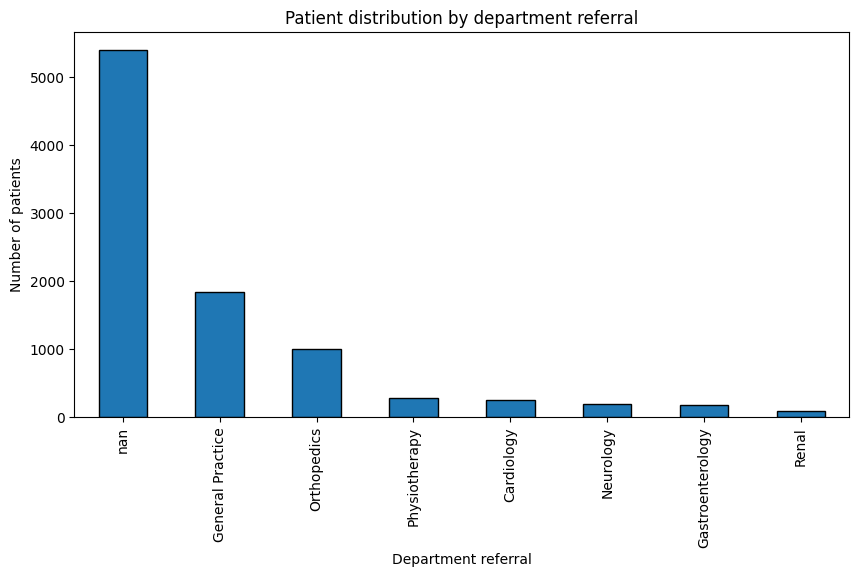

                     Count  Mean  Median
Department Referral                     
Cardiology              71  5.14     6.0
Gastroenterology        54  5.80     6.0
General Practice       503  5.06     5.0
Neurology               53  5.28     5.0
Orthopedics            290  4.86     5.0
Physiotherapy           83  4.99     5.0
Renal                   23  4.57     4.0


<Figure size 1200x600 with 0 Axes>

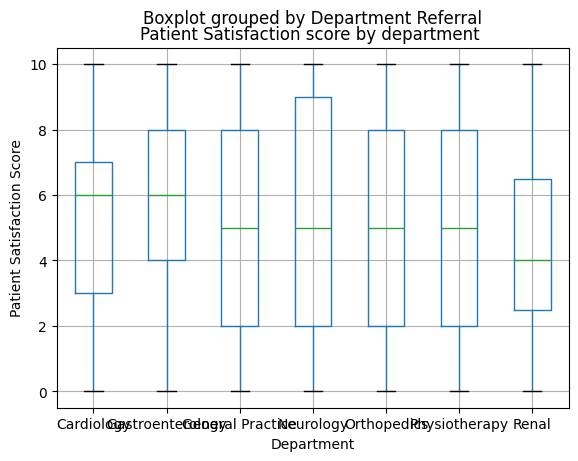

In [26]:
#next we have to do the department refferal analysis
department_counts=df["Department Referral"].value_counts(dropna=False)
print(department_counts)
department_percentage=(df["Department Referral"].value_counts(normalize=True,dropna=False)*100)
print(department_percentage.round(2))


# ok now we want to create the bar graph visualization
plt.figure(figsize=(10,5))
department_counts.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Patient distribution by department referral")
plt.xlabel("Department referral")
plt.ylabel("Number of patients")
plt.show()


# ok now i have to check the deoartment satisfaction
department_satisfaction=df.groupby("Department Referral")["Patient Satisfaction Score"].agg(
    Count="count",
    Mean="mean",
    Median="median"
)
print(department_satisfaction.round(2))

#department wise satisfaction box plot
plt.figure(figsize=(12,6))
df.boxplot(
    column="Patient Satisfaction Score",
    by="Department Referral"
)
plt.title("Patient Satisfaction score by department ")
plt.xlabel("Department")
plt.ylabel("Patient Satisfaction Score")
plt.show()

Patient Admission Flag
Admission        4612
Not Admission    4604
Name: count, dtype: int64
Patient Admission Flag
Admission        50.04
Not Admission    49.96
Name: proportion, dtype: float64


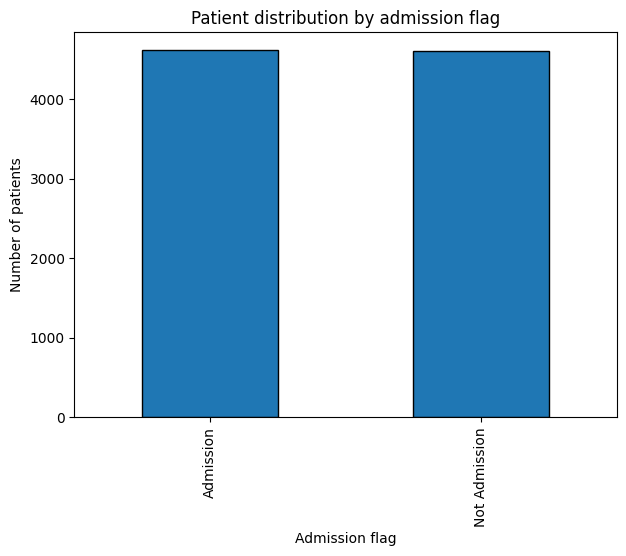

In [28]:
# ok now we want to create an admission flag distribution
admission_counts=df["Patient Admission Flag"].value_counts(dropna=False)
print(admission_counts)
admission_percentage=(df["Patient Admission Flag"].value_counts(normalize=True,dropna=False)*100)
print(admission_percentage.round(2))

plt.figure(figsize=(7,5))
admission_counts.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Patient distribution by admission flag")
plt.xlabel("Admission flag")
plt.ylabel("Number of patients")
plt.show()

In [30]:
#admission status vs satisfaction
admission_satisfaction=df.groupby("Patient Admission Flag")["Patient Satisfaction Score"].agg(
    Count="count",
    Mean="mean",
    Median="median"
)
print(admission_satisfaction.round(2))


                        Count  Mean  Median
Patient Admission Flag                     
Admission                1235  5.08     5.0
Not Admission            1282  4.91     5.0


<Figure size 800x500 with 0 Axes>

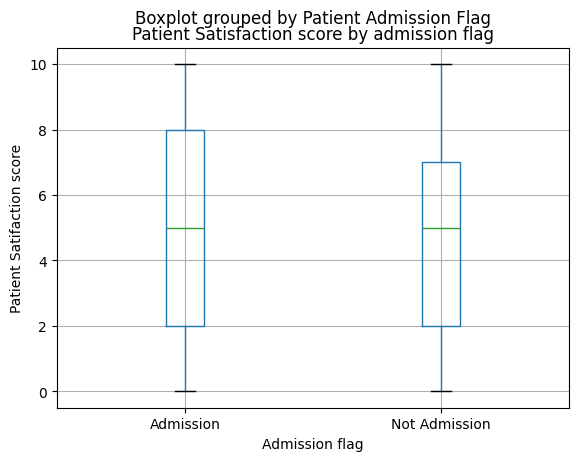

In [35]:
#create the box plot
plt.figure(figsize=(8,5))
df.boxplot(
    column="Patient Satisfaction Score",
    by="Patient Admission Flag"
)

plt.title("Patient Satisfaction score by admission flag")
plt.xlabel("Admission flag")
plt.ylabel("Patient Satifaction score")
plt.show()

In [36]:
#now we want to do the welch's test
from scipy.stats import ttest_ind
admission_satisfaction=df.loc[
    df["Patient Admission Flag"]=="Admission",
    "Patient Satisfaction Score"
].dropna()

not_admission_satisfaction=df.loc[
    df["Patient Admission Flag"] == "Not Admission",
    "Patient Satisfaction Score"
].dropna()

t_stat,p_value=ttest_ind(
    admission_satisfaction,
    not_admission_satisfaction,
    equal_var=False
)

print("t-statistics",t_stat)
print("p-value",p_value)

t-statistics 1.3311880824616185
p-value 0.18324834393149755


In [39]:
waittime_satisfaction = df[
    ["Patient Waittime", "Patient Satisfaction Score"]
].dropna()

print(waittime_satisfaction.describe())

       Patient Waittime  Patient Satisfaction Score
count       2517.000000                 2517.000000
mean          35.351212                    4.992054
std           14.852207                    3.138043
min           10.000000                    0.000000
25%           23.000000                    2.000000
50%           36.000000                    5.000000
75%           48.000000                    8.000000
max           60.000000                   10.000000


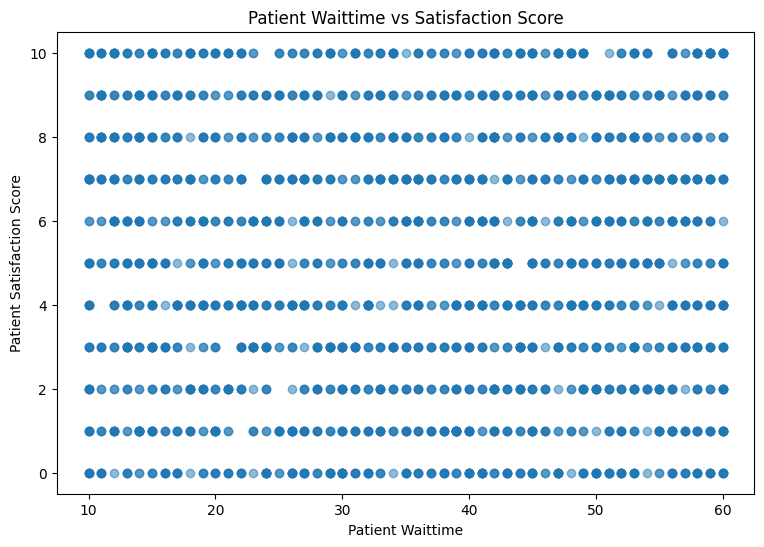

In [40]:
plt.figure(figsize=(9, 6))

plt.scatter(
    waittime_satisfaction["Patient Waittime"],
    waittime_satisfaction["Patient Satisfaction Score"],
    alpha=0.5
)

plt.title("Patient Waittime vs Satisfaction Score")
plt.xlabel("Patient Waittime")
plt.ylabel("Patient Satisfaction Score")

plt.show()

In [41]:
#correlation of waittime vs satisfaction
correlation=waittime_satisfaction["Patient Waittime"].corr(
    waittime_satisfaction["Patient Satisfaction Score"]

)
print ("Pearson correlation",round(correlation,4))

Pearson correlation -0.0212


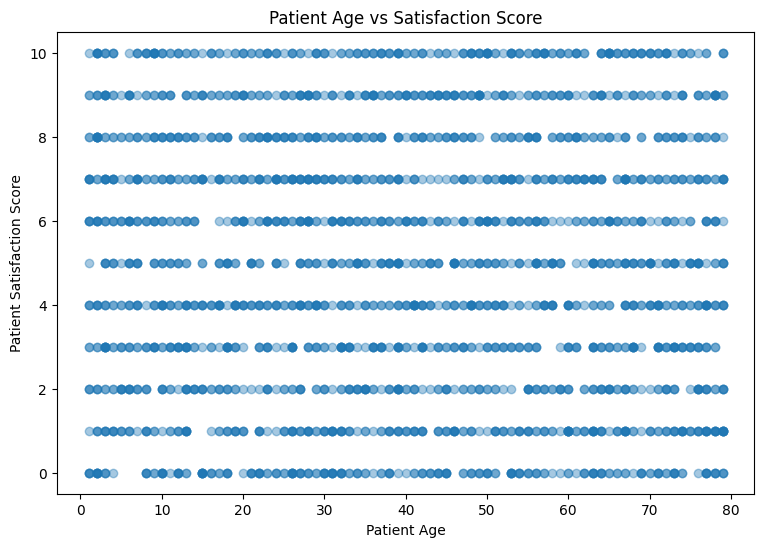

In [44]:
#patient Age vs Satisfaction
age_satisfaction=df[
    [
        "Patient Age",
        "Patient Satisfaction Score"
    ]
].dropna()

plt.figure(figsize=(9,6))
plt.scatter(
    age_satisfaction["Patient Age"],
    age_satisfaction["Patient Satisfaction Score"],
    alpha=0.4
)
plt.title("Patient Age vs Satisfaction Score")
plt.xlabel("Patient Age")
plt.ylabel("Patient Satisfaction Score")
plt.show()

In [45]:
#pearson correlation
age_correlation=age_satisfaction["Patient Age"].corr(
    age_satisfaction["Patient Satisfaction Score"]
)
print("Pearson Correlation:",round(age_correlation))

Pearson Correlation: 0


In [47]:
#correlation matrix
numeric_columns=[
    "Patient Age",
    "Patient Satisfaction Score",
    "Patient Waittime"
]
correlation_matrix=df[numeric_columns].corr()
print(correlation_matrix)

                            Patient Age  Patient Satisfaction Score  \
Patient Age                    1.000000                   -0.023644   
Patient Satisfaction Score    -0.023644                    1.000000   
Patient Waittime              -0.005636                   -0.021183   

                            Patient Waittime  
Patient Age                        -0.005636  
Patient Satisfaction Score         -0.021183  
Patient Waittime                    1.000000  


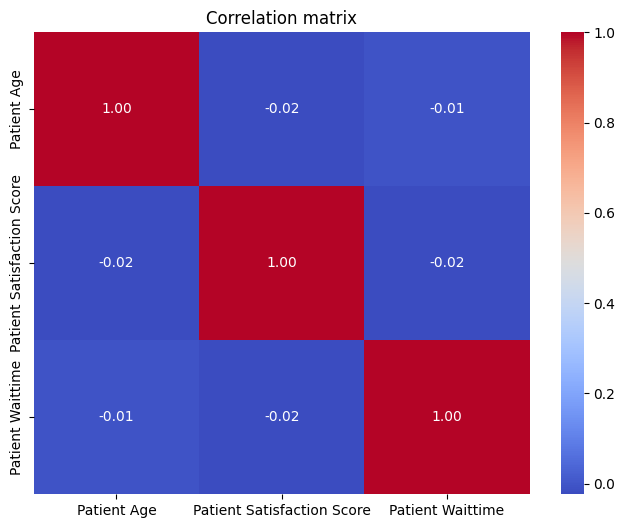

In [48]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation matrix")
plt.show()

# 5. EDA Findings and Business Insights

## Key Findings

1. The patient satisfaction score ranges from 0 to 10, with the available
   satisfaction scores showing a relatively distributed pattern across the scale.

2. The median patient satisfaction score is 5, indicating that the central
   satisfaction level among records with available scores is around 5.

3. Patient age ranges from 1 to 79 years, with a median age of 39 years.

4. Patient waiting time ranges from 10 to 60 minutes. IQR-based analysis
   did not identify statistical outliers in the observed waiting-time data.

5. The gender distribution is relatively balanced between male and female
   patients.

6. Descriptive comparison of satisfaction by gender showed very similar
   median satisfaction scores. The Welch's t-test did not provide sufficient
   evidence of a statistically significant difference in mean satisfaction
   between the two gender groups.

7. One-way ANOVA across race groups did not provide sufficient evidence of
   a statistically significant difference in mean satisfaction scores.

8. Admission and non-admission groups had similar satisfaction distributions,
   with no statistically significant difference identified by the comparison
   test.

9. The correlation between patient age and satisfaction was approximately
   -0.02, indicating a negligible linear association.

10. The correlation between patient waiting time and satisfaction was
    approximately -0.02, also indicating a negligible linear association.

## Data Quality Observations

- Patient Admission Date contains a substantial proportion of missing values.
- Department Referral also contains a substantial proportion of missing values.
- Patient Satisfaction Score contains a large proportion of missing values.
- The `Femaleemale` gender category was identified and corrected to `Female`.
- No duplicate Patient IDs were identified.

## Limitations

- A large proportion of patient satisfaction scores are missing.
- Patient Admission Date has substantial missingness, limiting reliable
  date-based analysis.
- Department Referral has substantial missingness.
- Correlation analysis measures linear association and does not establish
  causation.
- Statistical significance does not necessarily imply practical or
  business significance.
- The observed dataset may not represent all hospital patients or
  healthcare settings.

## EDA Conclusion

The EDA provides an understanding of patient demographics, waiting time,
satisfaction patterns, categorical distributions, missing data, and
relationships among numerical variables.

The next stage is to prepare the dataset for predictive modeling through
feature engineering, target definition, data splitting, and model training.

In [54]:
!gh repo clone albinpsabu/hospital-patient-satisfaction-analytics

To get started with GitHub CLI, please run:  gh auth login
Alternatively, populate the GH_TOKEN environment variable with a GitHub API authentication token.


In [55]:
processed_path = "/content/drive/MyDrive/datasets2026/healthcare_patient_flow_cleaned.csv"

df.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved successfully.")
print("Path:", processed_path)

Processed dataset saved successfully.
Path: /content/drive/MyDrive/datasets2026/healthcare_patient_flow_cleaned.csv


In [57]:
#first we want to define the target
target="Patient Satisfaction Score"
print("Target variable:",target)


print("Total records:",len(df))
print("Available target values:",df[target].notna().sum())
print("Missing target values:",df[target].isna().sum())

Target variable: Patient Satisfaction Score
Total records: 9216
Available target values: 2517
Missing target values: 6699


In [58]:
# remove the rows where taget is missing
model_df=df.dropna(
    subset=[target]
).copy()
print("Modeling dataset shape:",model_df.shape)

Modeling dataset shape: (2517, 12)


In [59]:
print(model_df[target].value_counts().sort_index())

Patient Satisfaction Score
0.0     222
1.0     246
2.0     204
3.0     228
4.0     248
5.0     221
6.0     231
7.0     256
8.0     218
9.0     222
10.0    221
Name: count, dtype: int64


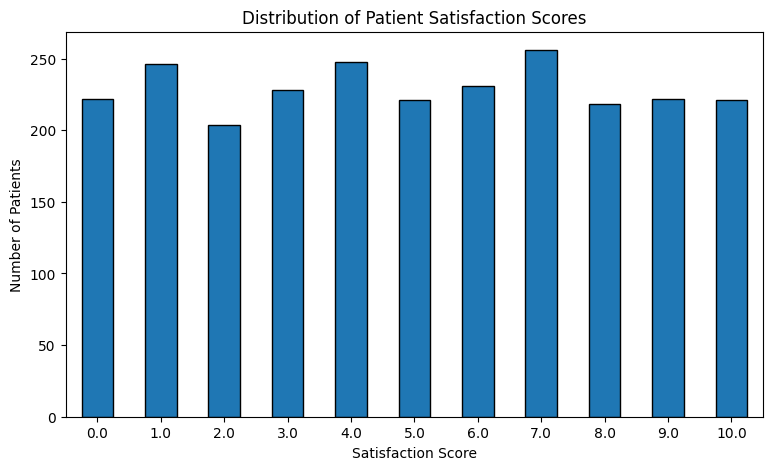

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

model_df[target].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Patient Satisfaction Scores")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [61]:
numerical_features = [
    "Patient Age",
    "Patient Waittime"
]

categorical_features = [
    "Patient Gender",
    "Patient Race",
    "Department Referral",
    "Patient Admission Flag"
]

target = "Patient Satisfaction Score"

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget:")
print(target)

Numerical Features:
['Patient Age', 'Patient Waittime']

Categorical Features:
['Patient Gender', 'Patient Race', 'Department Referral', 'Patient Admission Flag']

Target:
Patient Satisfaction Score


In [62]:
#ok next we want to split data into test and train data
#ok for that we want to create the  x and y
x=model_df[numerical_features + categorical_features]
y=model_df[target]
print("X shape:",x.shape)
print("y shape:",y.shape)

X shape: (2517, 6)
y shape: (2517,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:",x_train.shape)
print("X_test:",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

In [63]:
from sklearn.impute import SimpleImputer

numerical_imputer = SimpleImputer(
    strategy="median"
)

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

print("Imputers created successfully.")

Imputers created successfully.
